# Text-to-SQL: Dynamic RAG Few-Shot + Self-Correction
Pipeline chạy trên Kaggle. Yêu cầu: bật **Internet** trong notebook settings, thêm **Secrets** cho API key (Gemini/OpenAI).

In [37]:
!pip install -q -U datasets faiss-cpu sentence-transformers tenacity google-genai openai pandas tqdm statsmodels

In [38]:
import os, json, sqlite3, time, re, signal
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# ---- CONFIG ----
LLM_PROVIDER = "gemini"   # "gemini" | "openai"
LLM_MODEL = "gemini-2.5-flash"   # hoặc "gemini-3-pro-preview" (mạnh hơn, chậm/đắt hơn) | "gpt-4o-2024-08-06"
EMBED_MODEL = "all-MiniLM-L6-v2"
TOP_K = 5
MAX_ROUNDS = 3
TIMEOUT_SEC = 5
SAMPLE_SIZE = 300   # số query dev set dùng để eval (tăng nếu đủ thời gian/budget)
SEED = 42
WORK_DIR = Path("/kaggle/working")
DB_DIR = WORK_DIR / "spider_dbs"

# ---- API KEY (Kaggle Secrets) ----
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
if LLM_PROVIDER == "gemini":
    from google import genai as google_genai
    from google.genai import types as google_genai_types
    gemini_client = google_genai.Client(api_key=secrets.get_secret("GEMINI_API_KEY"))
else:
    from openai import OpenAI
    client = OpenAI(api_key=secrets.get_secret("OPENAI_API_KEY"))


## 1. Data Ingestion

In [39]:
from datasets import load_dataset

spider = load_dataset("spider")
train_ds = spider["train"]
dev_ds = spider["validation"]

print(f"Train: {len(train_ds)} | Dev: {len(dev_ds)}")
print(train_ds[0])


Train: 7000 | Dev: 1034
{'db_id': 'department_management', 'query': 'SELECT count(*) FROM head WHERE age  >  56', 'question': 'How many heads of the departments are older than 56 ?', 'query_toks': ['SELECT', 'count', '(', '*', ')', 'FROM', 'head', 'WHERE', 'age', '>', '56'], 'query_toks_no_value': ['select', 'count', '(', '*', ')', 'from', 'head', 'where', 'age', '>', 'value'], 'question_toks': ['How', 'many', 'heads', 'of', 'the', 'departments', 'are', 'older', 'than', '56', '?']}


In [40]:
# Tai truc tiep tu Google Drive chinh thu (Yale-LILY) - khong can add Kaggle Data source
!pip install -q gdown
import subprocess, zipfile

SPIDER_GDRIVE_ID = "1403EGqzIDoHMdQF4c9Bkyl7dZLZ5Wt6J"  # link chinh thuc: yale-lily.github.io/spider
ZIP_PATH = WORK_DIR / "spider.zip"
EXTRACT_DIR = WORK_DIR / "spider_extracted"

DB_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    result = subprocess.run(
        ["gdown", f"https://drive.google.com/uc?id={SPIDER_GDRIVE_ID}", "-O", str(ZIP_PATH)],
        capture_output=True, text=True
    )
    print(result.stdout[-2000:], result.stderr[-2000:])

assert ZIP_PATH.exists() and ZIP_PATH.stat().st_size > 10_000_000, (
    "gdown fail (Google Drive co the chan qua nhieu request quota). "
    "FALLBACK: vao https://drive.google.com/file/d/1403EGqzIDoHMdQF4c9Bkyl7dZLZ5Wt6J/view "
    "tai thu cong ve may -> upload len Kaggle Dataset rieng -> Add Data -> "
    "roi set SPIDER_DB_ROOT tro thang toi thu muc do (bo qua cell nay)."
)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

# File zip giai nen ra thu muc con ten "spider" chua database/
found = list(EXTRACT_DIR.rglob("database"))
assert found, f"Khong tim thay thu muc 'database' trong zip da giai nen tai {EXTRACT_DIR}"
SPIDER_DB_ROOT = found[0]
print("SPIDER_DB_ROOT =", SPIDER_DB_ROOT, "| so DB:", len(list(SPIDER_DB_ROOT.iterdir())))


SPIDER_DB_ROOT = /kaggle/working/spider_extracted/spider_data/database | so DB: 166


In [41]:
def get_schema_str(db_id: str, db_root: Path) -> str:
    """Tra ve schema dang nen: table(col:type, col:type)"""
    db_path = db_root / db_id / f"{db_id}.sqlite"
    if not db_path.exists():
        return ""
    conn = sqlite3.connect(str(db_path))
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = [r[0] for r in cur.fetchall() if not r[0].startswith("sqlite_")]
    parts = []
    for t in tables:
        cur.execute(f'PRAGMA table_info("{t}")')
        cols = cur.fetchall()  # cid, name, type, notnull, dflt, pk
        col_str = ", ".join([f"{c[1]}:{c[2]}" for c in cols])
        parts.append(f"{t}({col_str})")
    conn.close()
    return " | ".join(parts)

# Cache schema cho tat ca db_id xuat hien trong train+dev
all_db_ids = set(train_ds["db_id"]) | set(dev_ds["db_id"])
schema_cache = {}
for db_id in tqdm(all_db_ids, desc="Caching schemas"):
    schema_cache[db_id] = get_schema_str(db_id, SPIDER_DB_ROOT)

schema_cache_path = WORK_DIR / "schema_cache.json"
schema_cache_path.write_text(json.dumps(schema_cache, ensure_ascii=False))
print(f"Cached {len(schema_cache)} schemas -> {schema_cache_path}")


Caching schemas:   0%|          | 0/160 [00:00<?, ?it/s]

Cached 160 schemas -> /kaggle/working/schema_cache.json


In [42]:
# Chuan hoa train_pairs.jsonl (dung lam nguon retrieval)
train_pairs = []
for ex in train_ds:
    train_pairs.append({
        "question": ex["question"],
        "db_id": ex["db_id"],
        "gold_sql": ex["query"],
        "schema": schema_cache.get(ex["db_id"], "")
    })

train_pairs_path = WORK_DIR / "train_pairs.jsonl"
with open(train_pairs_path, "w") as f:
    for p in train_pairs:
        f.write(json.dumps(p, ensure_ascii=False) + "\n")
print(f"{len(train_pairs)} train pairs -> {train_pairs_path}")


7000 train pairs -> /kaggle/working/train_pairs.jsonl


## 2. Vector DB Setup (FAISS + MiniLM)

In [43]:
from sentence_transformers import SentenceTransformer
import faiss

embedder = SentenceTransformer(EMBED_MODEL)

questions = [p["question"] for p in train_pairs]
embeddings = embedder.encode(
    questions, batch_size=64, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True  # normalize -> IP = cosine
)

dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings.astype(np.float32))

faiss.write_index(index, str(WORK_DIR / "spider_train.index"))
print(f"FAISS index: {index.ntotal} vectors, dim={dim}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/110 [00:00<?, ?it/s]

FAISS index: 7000 vectors, dim=384


In [44]:
def retrieve_topk(question: str, db_id: str, k: int = TOP_K, over_fetch: int = 40):
    """Retrieve top-k (question, sql) pairs cung db_id. Fallback global neu thieu."""
    q_emb = embedder.encode([question], normalize_embeddings=True).astype(np.float32)
    scores, idxs = index.search(q_emb, over_fetch)
    same_db = [train_pairs[i] for i in idxs[0] if train_pairs[i]["db_id"] == db_id]
    if len(same_db) >= k:
        return same_db[:k]
    # fallback: bo sung tu top global neu thieu
    extra = [train_pairs[i] for i in idxs[0] if train_pairs[i]["db_id"] != db_id]
    return (same_db + extra)[:k]


## 3. Prompt Construction

In [45]:
SYSTEM_PROMPT = """Ban la mot chuyen gia sinh SQL cho SQLite.
Chi tra ve DUY NHAT cau lenh SQL, khong giai thich, khong markdown fence.
Tuan thu dung cu phap SQLite (khong dung cu phap MySQL/Postgres-only)."""

def build_prompt(question, db_id, k=TOP_K, mode="dynamic"):
    schema = schema_cache.get(db_id, "")
    if mode == "zero_shot":
        examples_str = ""
    elif mode in ("static", "static_correction"):
        # 5 vi du co dinh dau tien cua train set (khong lien quan db)
        ex = train_pairs[:k]
        examples_str = "\n".join([f"Q: {e['question']}\nSQL: {e['gold_sql']}" for e in ex])
    else:  # dynamic
        ex = retrieve_topk(question, db_id, k)
        examples_str = "\n".join([f"Q: {e['question']}\nSQL: {e['gold_sql']}" for e in ex])

    prompt = f"""{SYSTEM_PROMPT}

Schema (database: {db_id}):
{schema}

Vi du:
{examples_str}

Cau hoi: {question}
SQL:"""
    return prompt


## 4. LLM Interface

In [46]:
from tenacity import retry, wait_exponential, stop_after_attempt

def clean_sql(text: str) -> str:
    text = text.strip()
    text = re.sub(r"^```sql|^```|```$", "", text, flags=re.MULTILINE).strip()
    return text

@retry(wait=wait_exponential(multiplier=2, min=2, max=30), stop=stop_after_attempt(5))
def call_llm(prompt: str) -> str:
    try:
        if LLM_PROVIDER == "gemini":
            resp = gemini_client.models.generate_content(
                model=LLM_MODEL,
                contents=prompt,
                config=google_genai_types.GenerateContentConfig(temperature=0)
            )
            return clean_sql(resp.text)
        else:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                temperature=0,
                messages=[{"role": "user", "content": prompt}]
            )
            return clean_sql(resp.choices[0].message.content)
    except Exception as e:
        print(f"[call_llm ERROR] {type(e).__name__}: {e}")  # in loi goc truoc khi tenacity retry/nuot mat
        raise


## 5. SQLite Execution Engine

In [47]:
import threading

def try_execute(sql: str, db_id: str, db_root: Path = None, timeout=TIMEOUT_SEC):
    # Dung threading.Timer + conn.interrupt() thay vi signal.alarm():
    # signal.alarm() chi chay duoc o main thread, se loi khi goi tu ThreadPoolExecutor worker.
    db_root = db_root or SPIDER_DB_ROOT
    db_path = db_root / db_id / f"{db_id}.sqlite"
    conn = sqlite3.connect(str(db_path), check_same_thread=False)
    timer = threading.Timer(timeout, conn.interrupt)
    timer.start()
    try:
        cur = conn.cursor()
        cur.execute(sql)
        rows = cur.fetchall()
        return rows, None
    except sqlite3.OperationalError as e:
        if "interrupted" in str(e).lower():
            return None, "Query timeout"
        return None, str(e)
    except Exception as e:
        return None, str(e)
    finally:
        timer.cancel()
        conn.close()

def result_match(pred_rows, gold_rows) -> bool:
    if pred_rows is None or gold_rows is None:
        return False
    return set(map(tuple, pred_rows)) == set(map(tuple, gold_rows))


## 6. Generation + Error-Driven Self-Correction

In [48]:
def generate_sql(question, db_id, k=TOP_K, mode="dynamic", max_rounds=MAX_ROUNDS, trace_log=None):
    prompt = build_prompt(question, db_id, k=k, mode=mode)
    use_correction = mode in ("dynamic_correction", "static_correction")

    sql, err, rounds_used = None, None, 0
    for r in range(max_rounds if use_correction else 1):
        sql = call_llm(prompt)
        rows, err = try_execute(sql, db_id)
        rounds_used = r
        if trace_log is not None:
            trace_log.append({
                "question": question, "db_id": db_id, "round": r,
                "sql": sql, "error": err
            })
        if err is None:
            return sql, rows, rounds_used, "success"
        if not use_correction:
            break
        prompt += f"\n\n-- Cau SQL truoc bi loi:\n{sql}\n-- Loi tra ve:\n{err}\n-- Sua lai, chi tra ve SQL:"
    return sql, None, rounds_used, "failed"


## 7. Batch Runner — 4 Ablation Conditions

In [49]:
CONDITIONS = {
    "E0_zero_shot":          {"mode": "zero_shot",         "k": 0},
    "E1_static_fewshot":     {"mode": "static",            "k": TOP_K},
    "E2_dynamic_fewshot":    {"mode": "dynamic",            "k": TOP_K},
    "E3_dynamic_correction": {"mode": "dynamic_correction", "k": TOP_K},
}

# Lay sample co dieu kien tu dev set (giu nguyen ti le hardness neu co field)
np.random.seed(SEED)
dev_indices = np.random.choice(len(dev_ds), size=min(SAMPLE_SIZE, len(dev_ds)), replace=False)
eval_set = [dev_ds[int(i)] for i in dev_indices]
print(f"Eval sample: {len(eval_set)} queries")


Eval sample: 300 queries


In [50]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def run_condition(cond_name, cond_cfg, eval_set, max_workers=8):
    results, traces = [], []
    def _run_one(ex):
        trace_log = []
        t0 = time.time()
        sql, rows, rounds_used, status = generate_sql(
            ex["question"], ex["db_id"],
            k=cond_cfg["k"], mode=cond_cfg["mode"], trace_log=trace_log
        )
        latency = time.time() - t0
        gold_rows, gold_err = try_execute(ex["query"], ex["db_id"])
        ex_match = result_match(rows, gold_rows) if status == "success" else False
        return {
            "condition": cond_name,
            "question": ex["question"],
            "db_id": ex["db_id"],
            "gold_sql": ex["query"],
            "pred_sql": sql,
            "EX": int(ex_match),
            "rounds_used": rounds_used,
            "status": status,
            "latency_sec": round(latency, 3),
        }, trace_log

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_run_one, ex) for ex in eval_set]
        for f in tqdm(as_completed(futures), total=len(futures), desc=cond_name):
            res, trace_log = f.result()
            results.append(res)
            traces.extend(trace_log)
    return results, traces

all_results, all_traces = [], []
for cond_name, cond_cfg in CONDITIONS.items():
    res, tr = run_condition(cond_name, cond_cfg, eval_set)
    all_results.extend(res)
    all_traces.extend(tr)
    # checkpoint sau moi condition (phong crash/rate-limit giua chung)
    pd.DataFrame(all_results).to_csv(WORK_DIR / "results_checkpoint.csv", index=False)


E0_zero_shot:   0%|          | 0/300 [00:00<?, ?it/s]

E1_static_fewshot:   0%|          | 0/300 [00:00<?, ?it/s]

E2_dynamic_fewshot:   0%|          | 0/300 [00:00<?, ?it/s]

[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


E3_dynamic_correction:   0%|          | 0/300 [00:00<?, ?it/s]

[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is cur

## 8. Save Outputs

In [51]:
results_df = pd.DataFrame(all_results)
traces_df = pd.DataFrame(all_traces)

results_df.to_csv(WORK_DIR / "results_full.csv", index=False)
traces_df.to_csv(WORK_DIR / "traces_full.csv", index=False)

summary = results_df.groupby("condition").agg(
    EX_mean=("EX", "mean"),
    avg_rounds=("rounds_used", "mean"),
    avg_latency=("latency_sec", "mean"),
    n=("EX", "count")
).reset_index()
print(summary)
summary.to_csv(WORK_DIR / "summary.csv", index=False)


               condition   EX_mean  avg_rounds  avg_latency    n
0           E0_zero_shot  0.776667    0.000000     1.503183  300
1      E1_static_fewshot  0.800000    0.000000     1.484530  300
2     E2_dynamic_fewshot  0.800000    0.000000     1.456330  300
3  E3_dynamic_correction  0.806667    0.003333     1.686553  300


## 9. Hardness Classification (Table 1, Fig 1)
Dùng đúng bộ phân loại chính thức của Spider (`process_sql.py` + `evaluation.py` từ repo taoyds/spider) — không tự chế heuristic, để số liệu so sánh được với literature.

In [52]:
!git clone --depth 1 -q https://github.com/taoyds/spider.git /kaggle/working/spider_eval
import sys
sys.path.insert(0, "/kaggle/working/spider_eval")
from process_sql import get_schema, Schema, get_sql
from evaluation import Evaluator
evaluator = Evaluator()

def compute_hardness(sql_query: str, db_id: str, db_root=None):
    db_root = db_root or SPIDER_DB_ROOT
    try:
        db_path = db_root / db_id / f"{db_id}.sqlite"
        schema = Schema(get_schema(str(db_path)))
        parsed = get_sql(schema, sql_query)
        return evaluator.eval_hardness(parsed)
    except Exception:
        return "unknown"  # gold SQL loi parse hiem gap, danh dau de loai khoi bang thay vi crash

results_df = pd.read_csv(WORK_DIR / "results_full.csv")
tqdm.pandas(desc="Classifying hardness")
results_df["hardness"] = results_df.progress_apply(
    lambda r: compute_hardness(r["gold_sql"], r["db_id"]), axis=1
)
results_df.to_csv(WORK_DIR / "results_full.csv", index=False)
print(results_df["hardness"].value_counts())
print(results_df.groupby(["condition", "hardness"])["EX"].mean())


fatal: destination path '/kaggle/working/spider_eval' already exists and is not an empty directory.


Classifying hardness:   0%|          | 0/1200 [00:00<?, ?it/s]

hardness
medium    488
easy      320
extra     200
hard      192
Name: count, dtype: int64
condition              hardness
E0_zero_shot           easy        0.925000
                       extra       0.580000
                       hard        0.687500
                       medium      0.795082
E1_static_fewshot      easy        0.950000
                       extra       0.620000
                       hard        0.729167
                       medium      0.803279
E2_dynamic_fewshot     easy        0.925000
                       extra       0.560000
                       hard        0.729167
                       medium      0.844262
E3_dynamic_correction  easy        0.937500
                       extra       0.580000
                       hard        0.708333
                       medium      0.852459
Name: EX, dtype: float64


## 10. K-Sweep — EX vs Top-K (Fig 2)
Chỉ chạy trên E2 (dynamic) và E3 (dynamic+correction) — E0/E1 không phụ thuộc K. Dùng subset nhỏ hơn `eval_set` chính để tiết kiệm budget/thời gian; nêu rõ điều này trong phần Limitations.

In [53]:
K_VALUES = [1, 3, 5, 8, 10]
KSWEEP_SAMPLE_SIZE = 100  # < SAMPLE_SIZE chinh de tiet kiem API budget; ghi ro trong Limitations

np.random.seed(SEED)
ksweep_indices = np.random.choice(len(dev_ds), size=min(KSWEEP_SAMPLE_SIZE, len(dev_ds)), replace=False)
ksweep_eval_set = [dev_ds[int(i)] for i in ksweep_indices]

ksweep_results = []
for k in K_VALUES:
    for cond_name, mode in [("E2_dynamic_fewshot", "dynamic"), ("E3_dynamic_correction", "dynamic_correction")]:
        run_name = f"{cond_name}_K{k}"
        res, _ = run_condition(run_name, {"mode": mode, "k": k}, ksweep_eval_set)
        ksweep_results.extend(res)
        pd.DataFrame(ksweep_results).to_csv(WORK_DIR / "ksweep_checkpoint.csv", index=False)

ksweep_df = pd.DataFrame(ksweep_results)
ksweep_df.to_csv(WORK_DIR / "ksweep_full.csv", index=False)

ksweep_df["base_condition"] = ksweep_df["condition"].str.extract(r"(E[23]_\w+?)_K\d+")
ksweep_df["k"] = ksweep_df["condition"].str.extract(r"_K(\d+)$").astype(int)
ksweep_summary = ksweep_df.groupby(["base_condition", "k"])["EX"].mean()
print(ksweep_summary)


E2_dynamic_fewshot_K1:   0%|          | 0/100 [00:00<?, ?it/s]

E3_dynamic_correction_K1:   0%|          | 0/100 [00:00<?, ?it/s]

E2_dynamic_fewshot_K3:   0%|          | 0/100 [00:00<?, ?it/s]

[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is cur

E3_dynamic_correction_K3:   0%|          | 0/100 [00:00<?, ?it/s]

...

E2_dynamic_fewshot_K8:   0%|          | 0/100 [00:00<?, ?it/s]

E3_dynamic_correction_K8:   0%|          | 0/100 [00:00<?, ?it/s]

E2_dynamic_fewshot_K10:   0%|          | 0/100 [00:00<?, ?it/s]

E3_dynamic_correction_K10:   0%|          | 0/100 [00:00<?, ?it/s]

base_condition         k 
E2_dynamic_fewshot     1     0.79
                       3     0.77
                       5     0.75
                       8     0.76
                       10    0.78
E3_dynamic_correction  1     0.79
                       3     0.77
                       5     0.77
                       8     0.74
                       10    0.77
Name: EX, dtype: float64


## 11. Failure Taxonomy (Fig 5)
Hai loại lỗi cần tách riêng: (a) lỗi **execution-time** (bắt tự động từ traceback SQLite), (b) lỗi **semantic** — SQL chạy được nhưng sai kết quả (EX=0, status=success) — loại này bắt buộc code tay, không tự động hoá được đáng tin cậy.

In [54]:
traces_df = pd.read_csv(WORK_DIR / "traces_full.csv")

def classify_error(error_msg):
    if pd.isna(error_msg):
        return "success"
    e = str(error_msg).lower()
    if "timeout" in e:
        return "timeout"
    if "no such column" in e or "no such table" in e or "ambiguous column" in e:
        return "wrong_schema_link"
    if "misuse of aggregate" in e or "group by" in e:
        return "wrong_aggregation"
    if "syntax error" in e or " near " in e:
        return "syntax_error"

    if "join" in e:
        return "wrong_join"
    return "other_execution_error"

traces_df["error_category"] = traces_df["error"].apply(classify_error)
traces_df.to_csv(WORK_DIR / "traces_full.csv", index=False)
print("Execution-error taxonomy:")
print(traces_df[traces_df["error_category"] != "success"]["error_category"].value_counts())


Execution-error taxonomy:
error_category
wrong_schema_link    1
Name: count, dtype: int64


In [55]:
print("Tong so dong traces_df:", len(traces_df))
print(traces_df["error"].isna().value_counts())  # True = success, False = co loi
print(traces_df.head())

Tong so dong traces_df: 1201
error
True     1200
False       1
Name: count, dtype: int64
                                            question  \
0  What is the zip code of the address in the cit...   
1  What is the maximum accelerate for different n...   
2  Show all paragraph texts for the document "Cus...   
3  Find the first name and country code of the ol...   
4  Find the program which most number of students...   

                          db_id  round  \
0  student_transcripts_tracking      0   
1                         car_1      0   
2          cre_Doc_Template_Mgt      0   
3                         wta_1      0   
4  student_transcripts_tracking      0   

                                                 sql error error_category  
0  SELECT zip_postcode FROM Addresses WHERE city ...   NaN        success  
1  SELECT Cylinders, MAX(Accelerate) FROM cars_da...   NaN        success  
2  SELECT T1.Paragraph_Text FROM Paragraphs AS T1...   NaN        success  
3  SELECT first_n

In [56]:
# Sample de code tay: SQL chay duoc nhung ket qua sai (loi semantic, khong bat duoc tu traceback)
semantic_fail = results_df[(results_df["status"] == "success") & (results_df["EX"] == 0)]
manual_sample = semantic_fail.sample(n=min(50, len(semantic_fail)), random_state=SEED)
manual_sample_path = WORK_DIR / "manual_review_semantic_errors.csv"
manual_sample[["condition", "question", "db_id", "gold_sql", "pred_sql", "hardness"]].to_csv(
    manual_sample_path, index=False
)
print(f"{len(manual_sample)} case semantic-fail -> {manual_sample_path}")
print("Mo file nay, them cot 'error_category' thu cong voi nhan: wrong_column_selected / wrong_filter_value / wrong_table_join / missing_groupby / other")


50 case semantic-fail -> /kaggle/working/manual_review_semantic_errors.csv
Mo file nay, them cot 'error_category' thu cong voi nhan: wrong_column_selected / wrong_filter_value / wrong_table_join / missing_groupby / other


In [57]:
# Goi y THO (KHONG phai nhan cuoi cung) de code tay nhanh hon: so sanh cau truc SELECT/WHERE/JOIN/GROUP BY
# giua gold_sql va pred_sql. Nguoi code tay VAN phai tu quyet dinh error_category cuoi cung.
import re as _re


def heuristic_hint(gold_sql, pred_sql):
    g, p = str(gold_sql).lower(), str(pred_sql).lower()
    hints = []
    if bool(_re.search(r"\bgroup by\b", g)) != bool(_re.search(r"\bgroup by\b", p)):
        hints.append("missing_groupby?")
    if bool(_re.search(r"\bjoin\b", g)) != bool(_re.search(r"\bjoin\b", p)):
        hints.append("wrong_table_join?")
    g_sel = _re.search(r"select(.*?)from", g, _re.S)
    p_sel = _re.search(r"select(.*?)from", p, _re.S)
    if g_sel and p_sel and g_sel.group(1).strip() != p_sel.group(1).strip():
        hints.append("wrong_column_selected?")
    if bool(_re.search(r"\bwhere\b", g)) != bool(_re.search(r"\bwhere\b", p)):
        hints.append("wrong_filter_value?")
    return ";".join(hints) if hints else "other?"


manual_sample = pd.read_csv(WORK_DIR / "manual_review_semantic_errors.csv")
manual_sample["heuristic_hint"] = manual_sample.apply(
    lambda r: heuristic_hint(r["gold_sql"], r["pred_sql"]), axis=1
)
manual_sample["error_category"] = ""  # <-- DIEN TAY o day: wrong_column_selected / wrong_filter_value / wrong_table_join / missing_groupby / other
manual_sample.to_csv(WORK_DIR / "manual_review_semantic_errors.csv", index=False)
print("Da them cot 'heuristic_hint' (goi y tho) va cot trong 'error_category' de dien tay.")
print("Mo file trong Kaggle Output/Excel, dien error_category cho tung dong, luu lai, dung cho Fig 5.")


Da them cot 'heuristic_hint' (goi y tho) va cot trong 'error_category' de dien tay.
Mo file trong Kaggle Output/Excel, dien error_category cho tung dong, luu lai, dung cho Fig 5.


**Output files** (`/kaggle/working/`):
- `results_full.csv` — per-query, per-condition kết quả **+ cột `hardness`** (dùng cho Fig 1, Table 1)
- `traces_full.csv` — log từng round self-correction **+ cột `error_category`** (dùng cho Fig 3, CSR-by-round)
- `summary.csv` — EX/latency/rounds trung bình theo condition
- `ksweep_full.csv` — kết quả sweep K ∈ {1,3,5,8,10} cho E2/E3 (dùng cho Fig 2)
- `manual_review_semantic_errors.csv` — 50 case cần code tay nhãn lỗi semantic (bổ sung cho Fig 5, làm thủ công ngoài notebook)

Đã đủ data cho toàn bộ Fig 1–5 và Table 1 trong Phase 3. Bước còn lại: code tay `manual_review_semantic_errors.csv`, rồi vẽ hình + viết manuscript.

## 12. E4 — Static Few-Shot + Self-Correction (tach interaction effect)

Muc dich: E3 = dynamic retrieval + correction. Neu chi co E0-E3, khong the tra loi cau hoi
"EX cao cua E3 la nho dynamic retrieval hay nho self-correction?" — day la cau hoi phan bien
gan nhu chac chan se bi hoi. E4 = static few-shot (giong E1) + correction (giong co che cua E3)
cho phep dung thiet ke 2x2:

|                 | No correction | + Correction |
|-----------------|---------------|--------------|
| Static retrieval  | E1            | **E4**       |
| Dynamic retrieval  | E2            | E3           |

Neu `(EX_E3 - EX_E2) > (EX_E4 - EX_E1)`: self-correction phat huy tot hon KHI ket hop voi
dynamic retrieval -> bang chung cho **interaction effect** (dong gop khong chi la additive don
gian tu 2 thanh phan doc lap) — day chinh la luan diem chinh de tra loi phe binh "novelty
incremental" trong Discussion.

**Khong can chay lai E0-E3** — chi chay E4 tren dung `eval_set` (cung SEED) roi merge vao
`results_full.csv` / `traces_full.csv`.

In [58]:
# Dam bao eval_set ton tai (phong truong hop kernel restart va chi load lai tu checkpoint)
if "eval_set" not in dir():
    np.random.seed(SEED)
    dev_indices = np.random.choice(len(dev_ds), size=min(SAMPLE_SIZE, len(dev_ds)), replace=False)
    eval_set = [dev_ds[int(i)] for i in dev_indices]
    print(f"[Rebuilt] Eval sample: {len(eval_set)} queries (SEED={SEED} -> giong het lan chay E0-E3)")

CONDITIONS_E4 = {
    "E4_static_correction": {"mode": "static_correction", "k": TOP_K},
}


In [59]:
def run_condition_full(cond_name, cond_cfg, eval_set, max_workers=8):
    """Giong run_condition() o Section 7, nhung traces CUNG duoc gan 'condition'
    (sua truoc bug thieu cot da biet o Phase 2, ap dung rieng cho E4)."""
    results, traces = [], []

    def _run_one(ex):
        trace_log = []
        t0 = time.time()
        sql, rows, rounds_used, status = generate_sql(
            ex["question"], ex["db_id"],
            k=cond_cfg["k"], mode=cond_cfg["mode"], trace_log=trace_log
        )
        latency = time.time() - t0
        gold_rows, gold_err = try_execute(ex["query"], ex["db_id"])
        ex_match = result_match(rows, gold_rows) if status == "success" else False
        for t in trace_log:
            t["condition"] = cond_name
        return {
            "condition": cond_name,
            "question": ex["question"],
            "db_id": ex["db_id"],
            "gold_sql": ex["query"],
            "pred_sql": sql,
            "EX": int(ex_match),
            "rounds_used": rounds_used,
            "status": status,
            "latency_sec": round(latency, 3),
        }, trace_log

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_run_one, ex) for ex in eval_set]
        for f in tqdm(as_completed(futures), total=len(futures), desc=cond_name):
            res, trace_log = f.result()
            results.append(res)
            traces.extend(trace_log)
    return results, traces


e4_results, e4_traces = run_condition_full(
    "E4_static_correction", CONDITIONS_E4["E4_static_correction"], eval_set
)
e4_results_df = pd.DataFrame(e4_results)
e4_traces_df = pd.DataFrame(e4_traces)
e4_traces_df.to_csv(WORK_DIR / "traces_e4_tagged.csv", index=False)
print(f"E4 overall EX (chua co hardness): {e4_results_df['EX'].mean():.4f}")


E4_static_correction:   0%|          | 0/300 [00:00<?, ?it/s]

E4 overall EX (chua co hardness): 0.7933


In [60]:
# Merge E4 vao results_full.csv / traces_full.csv + gan hardness cho cac dong moi
results_df = pd.read_csv(WORK_DIR / "results_full.csv")
traces_df = pd.read_csv(WORK_DIR / "traces_full.csv")

tqdm.pandas(desc="Hardness for E4")
e4_results_df["hardness"] = e4_results_df.progress_apply(
    lambda r: compute_hardness(r["gold_sql"], r["db_id"]), axis=1
)

results_df = pd.concat([results_df, e4_results_df], ignore_index=True)

# traces_full.csv (E0-E3) van thieu cot 'condition' (known gap, KHONG sua nguoc vi khong can chay
# lai E0-E3) -> chi them cot rong cho tuong thich schema khi concat voi traces E4 (co gan condition).
if "condition" not in traces_df.columns:
    traces_df["condition"] = np.nan
traces_df = pd.concat([traces_df, e4_traces_df], ignore_index=True)

results_df.to_csv(WORK_DIR / "results_full.csv", index=False)
traces_df.to_csv(WORK_DIR / "traces_full.csv", index=False)

summary = results_df.groupby("condition").agg(
    EX_mean=("EX", "mean"), avg_rounds=("rounds_used", "mean"),
    avg_latency=("latency_sec", "mean"), n=("EX", "count")
).reset_index()
print(summary)
summary.to_csv(WORK_DIR / "summary.csv", index=False)


Hardness for E4:   0%|          | 0/300 [00:00<?, ?it/s]

               condition   EX_mean  avg_rounds  avg_latency    n
0           E0_zero_shot  0.776667    0.000000     1.503183  300
1      E1_static_fewshot  0.800000    0.000000     1.484530  300
2     E2_dynamic_fewshot  0.800000    0.000000     1.456330  300
3  E3_dynamic_correction  0.806667    0.003333     1.686553  300
4   E4_static_correction  0.793333    0.000000     1.426340  300


## 13. Statistical Validity — McNemar's Test (EX theo cap dieu kien)

Spider EX la bien nhi phan theo tung cau hoi, va cac dieu kien duoc chay tren **cung mot
`eval_set`** -> day la du lieu paired binary, dung chinh xac gia dinh cua **McNemar's test**
(khong dung t-test/chi-square doc lap o day). Ket qua nay tra loi truc tiep phe binh
"statistical validity" trong phan Discussion/Results.

In [61]:
from statsmodels.stats.contingency_tables import mcnemar


def paired_ex(cond_a, cond_b, df=None):
    df = df if df is not None else results_df
    a = df[df["condition"] == cond_a].set_index(["question", "db_id"])["EX"]
    b = df[df["condition"] == cond_b].set_index(["question", "db_id"])["EX"]
    common = a.index.intersection(b.index)
    a, b = a.loc[common], b.loc[common]
    table = pd.crosstab(a, b)
    for i in (0, 1):
        if i not in table.index:
            table.loc[i] = 0
        if i not in table.columns:
            table[i] = 0
    table = table.loc[[0, 1], [0, 1]]
    result = mcnemar(table.values, exact=bool(table.values.min() < 25))
    return {
        "pair": f"{cond_a} vs {cond_b}", "n_matched": len(common),
        "EX_a": round(a.mean(), 3), "EX_b": round(b.mean(), 3),
        "statistic": round(float(result.statistic), 3), "p_value": round(float(result.pvalue), 4),
    }


pairs = [
    ("E0_zero_shot", "E1_static_fewshot"),
    ("E1_static_fewshot", "E2_dynamic_fewshot"),
    ("E2_dynamic_fewshot", "E3_dynamic_correction"),
    ("E1_static_fewshot", "E3_dynamic_correction"),
    ("E1_static_fewshot", "E4_static_correction"),
    ("E2_dynamic_fewshot", "E4_static_correction"),
    ("E3_dynamic_correction", "E4_static_correction"),
]
mcnemar_df = pd.DataFrame([paired_ex(a, b) for a, b in pairs])
print(mcnemar_df)
mcnemar_df.to_csv(WORK_DIR / "mcnemar_pairwise.csv", index=False)
print("\np < 0.05 -> khac biet EX giua 2 dieu kien co y nghia thong ke (khong chi la nhieu ngau nhien tren 300 mau).")


                                            pair  n_matched   EX_a   EX_b  \
0              E0_zero_shot vs E1_static_fewshot        300  0.777  0.800   
1        E1_static_fewshot vs E2_dynamic_fewshot        300  0.800  0.800   
2    E2_dynamic_fewshot vs E3_dynamic_correction        300  0.800  0.807   
3     E1_static_fewshot vs E3_dynamic_correction        300  0.800  0.807   
4      E1_static_fewshot vs E4_static_correction        300  0.800  0.793   
5     E2_dynamic_fewshot vs E4_static_correction        300  0.800  0.793   
6  E3_dynamic_correction vs E4_static_correction        300  0.807  0.793   

   statistic  p_value  
0        5.0   0.1435  
1       13.0   1.0000  
2        1.0   0.6250  
3       11.0   0.8388  
4        2.0   0.6875  
5       10.0   0.8318  
6        9.0   0.5235  

p < 0.05 -> khac biet EX giua 2 dieu kien co y nghia thong ke (khong chi la nhieu ngau nhien tren 300 mau).


### Interaction effect (bang chung chinh cho luan diem "khong incremental")

In [62]:
ex_means = results_df.groupby("condition")["EX"].mean()
delta_dynamic = ex_means["E3_dynamic_correction"] - ex_means["E2_dynamic_fewshot"]  # gain cua correction KHI co dynamic retrieval
delta_static = ex_means["E4_static_correction"] - ex_means["E1_static_fewshot"]      # gain cua correction KHI CHI co static retrieval

print(f"Correction gain WITH dynamic retrieval  (E3 - E2): {delta_dynamic:+.4f}")
print(f"Correction gain WITH static retrieval   (E4 - E1): {delta_static:+.4f}")
print(f"Interaction effect (difference-of-differences)   : {delta_dynamic - delta_static:+.4f}")
print("\nDung con so nay + p-value cua cap (E3 vs E2) va (E4 vs E1) o McNemar table ")
print("de viet luan diem Discussion: 'self-correction hieu qua hon ro ret khi ket hop voi dynamic")
print("retrieval, cho thay 2 thanh phan tuong tac (interaction), khong chi cong don gian (additive)'")
print("-- HOAC neu con so am/khong ro ret, phai chu dong thao luan dieu do (xem outline Phase 4 ben duoi).")


Correction gain WITH dynamic retrieval  (E3 - E2): +0.0067
Correction gain WITH static retrieval   (E4 - E1): -0.0067
Interaction effect (difference-of-differences)   : +0.0133

Dung con so nay + p-value cua cap (E3 vs E2) va (E4 vs E1) o McNemar table 
de viet luan diem Discussion: 'self-correction hieu qua hon ro ret khi ket hop voi dynamic
retrieval, cho thay 2 thanh phan tuong tac (interaction), khong chi cong don gian (additive)'
-- HOAC neu con so am/khong ro ret, phai chu dong thao luan dieu do (xem outline Phase 4 ben duoi).


# Phase 3: Visualization
Tất cả hình lưu PNG 300dpi vào `/kaggle/working/figures/` — dùng thẳng trong manuscript (LaTeX/Word).
**Lưu ý:** tránh dùng `.unstack()`/`.pivot()`/`sns.heatmap()` trên môi trường Kaggle hiện tại — bug tương thích `pandas.errors.Pandas4Warning` (đã gặp ở Phase 2) sẽ crash. Toàn bộ code dưới đây né hoàn toàn các hàm reshape đó.

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
FIG_DIR = WORK_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

results_df = pd.read_csv(WORK_DIR / "results_full.csv")
traces_df = pd.read_csv(WORK_DIR / "traces_full.csv")
ksweep_df = pd.read_csv(WORK_DIR / "ksweep_full.csv")
summary_df = pd.read_csv(WORK_DIR / "summary.csv")

CONDITION_ORDER = ["E0_zero_shot", "E1_static_fewshot", "E2_dynamic_fewshot", "E3_dynamic_correction", "E4_static_correction"]
HARDNESS_ORDER = ["easy", "medium", "hard", "extra"]


### Table 1 — EX theo condition × hardness

In [64]:
# Xay bang wide-form thu cong (KHONG dung .pivot()/.unstack() de tranh bug pandas)
grp = results_df.groupby(["condition", "hardness"])["EX"].mean().reset_index()
table1 = {}
for cond in CONDITION_ORDER:
    sub = grp[grp["condition"] == cond].set_index("hardness")["EX"]
    table1[cond] = {h: round(sub.get(h, float("nan")), 3) for h in HARDNESS_ORDER}
table1_df = pd.DataFrame(table1).T
table1_df["overall"] = results_df[results_df["condition"].isin(CONDITION_ORDER)].groupby("condition")["EX"].mean().reindex(CONDITION_ORDER).round(3)
print(table1_df)
table1_df.to_csv(WORK_DIR / "table1_ex_by_hardness.csv")


                        easy  medium   hard  extra  overall
E0_zero_shot           0.925   0.795  0.688   0.58    0.777
E1_static_fewshot      0.950   0.803  0.729   0.62    0.800
E2_dynamic_fewshot     0.925   0.844  0.729   0.56    0.800
E3_dynamic_correction  0.938   0.852  0.708   0.58    0.807
E4_static_correction   0.938   0.820  0.708   0.58    0.793


### Fig 1 — EX theo 4 setup, breakdown theo hardness

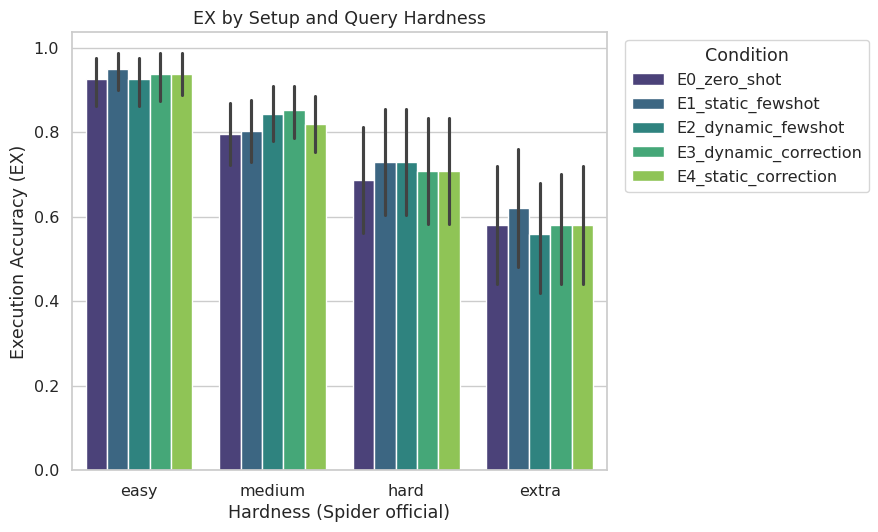

In [65]:
plt.figure(figsize=(9, 5.5))
plot_df = results_df[results_df["condition"].isin(CONDITION_ORDER)].copy()
plot_df["hardness"] = pd.Categorical(plot_df["hardness"], categories=HARDNESS_ORDER, ordered=True)
plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=CONDITION_ORDER, ordered=True)

ax = sns.barplot(data=plot_df, x="hardness", y="EX", hue="condition", errorbar=("ci", 95), palette="viridis")
ax.set_xlabel("Hardness (Spider official)")
ax.set_ylabel("Execution Accuracy (EX)")
ax.set_title("EX by Setup and Query Hardness")
ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_ex_by_hardness.png", dpi=300, bbox_inches="tight")
plt.show()


### Fig 2 — EX vs Top-K (E2 & E3)

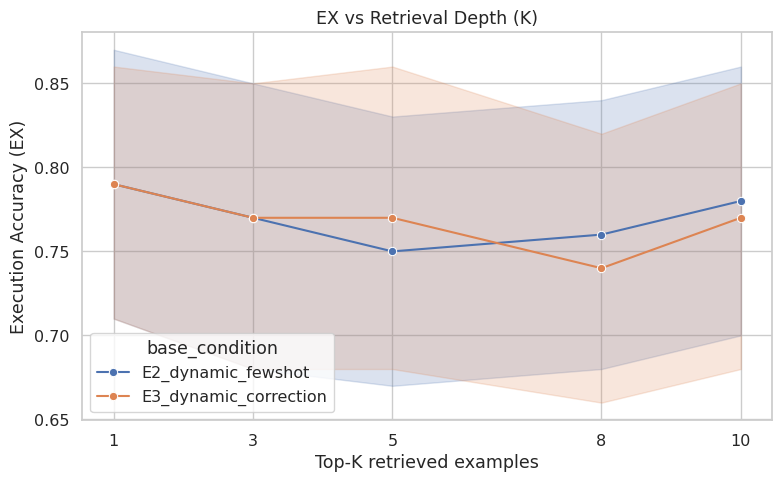

In [66]:
ksweep_df["base_condition"] = ksweep_df["condition"].str.extract(r"(E[23]_\w+?)_K\d+")
ksweep_df["k"] = ksweep_df["condition"].str.extract(r"_K(\d+)$").astype(int)

plt.figure(figsize=(8, 5))
ax = sns.lineplot(data=ksweep_df, x="k", y="EX", hue="base_condition", marker="o", errorbar=("ci", 95))
ax.set_xlabel("Top-K retrieved examples")
ax.set_ylabel("Execution Accuracy (EX)")
ax.set_title("EX vs Retrieval Depth (K)")
ax.set_xticks(sorted(ksweep_df["k"].unique()))
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_ex_vs_k.png", dpi=300, bbox_inches="tight")
plt.show()


### Chuẩn bị data cho Fig 3 (CSR-by-round)
`traces_full.csv` không gắn nhãn `condition` (bug thiết kế ở Phase 2) nên không tách được round-data riêng của E3. Chạy lại **chỉ E3** trên cùng `eval_set` — rẻ (~300 query), tận dụng `run_condition()` đã có sẵn trong kernel, không cần chạy lại 3 điều kiện còn lại.

In [67]:
# Chi chay lai E3 voi trace_log co gan condition, dung cho Fig 3
def run_condition_tagged(cond_name, cond_cfg, eval_set, max_workers=8):
    results, traces = [], []
    def _run_one(ex):
        trace_log = []
        sql, rows, rounds_used, status = generate_sql(
            ex["question"], ex["db_id"], k=cond_cfg["k"], mode=cond_cfg["mode"], trace_log=trace_log
        )
        for t in trace_log:
            t["condition"] = cond_name
        return trace_log
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_run_one, ex) for ex in eval_set]
        for f in tqdm(as_completed(futures), total=len(futures), desc=cond_name):
            traces.extend(f.result())
    return traces

e3_tagged_traces = run_condition_tagged(
    "E3_dynamic_correction", CONDITIONS["E3_dynamic_correction"], eval_set
)
e3_traces_df = pd.DataFrame(e3_tagged_traces)
e3_traces_df.to_csv(WORK_DIR / "traces_e3_tagged.csv", index=False)
print(e3_traces_df.groupby("round").size())


E3_dynamic_correction:   0%|          | 0/300 [00:00<?, ?it/s]

[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
[call_llm ERROR] ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is cur

### Fig 3 — Correction Success Rate (CSR) theo round

   round  success_rate    n
0      0      0.996667  300
1      1      1.000000    1


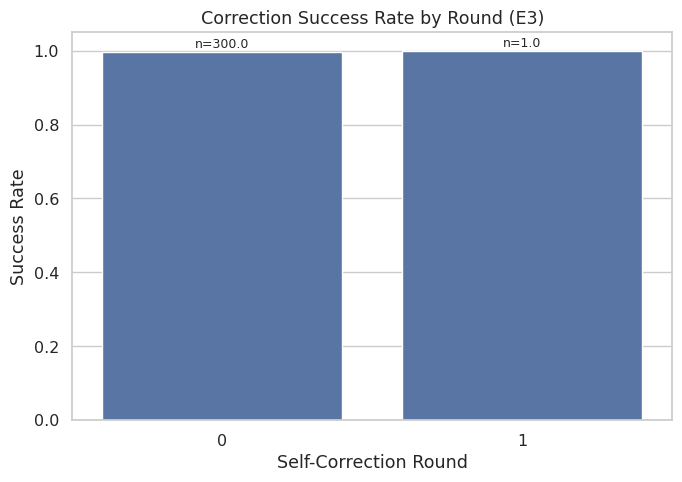

In [68]:
e3_traces_df = pd.read_csv(WORK_DIR / "traces_e3_tagged.csv")
e3_traces_df["success"] = e3_traces_df["error"].isna()

# CSR round r = ti le thanh cong TRONG SO cac query van con fail truoc do
csr_rows = []
for r in sorted(e3_traces_df["round"].unique()):
    round_df = e3_traces_df[e3_traces_df["round"] == r]
    csr_rows.append({"round": int(r), "success_rate": round_df["success"].mean(), "n": len(round_df)})
csr_df = pd.DataFrame(csr_rows)
print(csr_df)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=csr_df, x="round", y="success_rate", color="#4C72B0")
for i, row in csr_df.iterrows():
    ax.text(i, row["success_rate"] + 0.01, f"n={row['n']}", ha="center", fontsize=9)
ax.set_xlabel("Self-Correction Round")
ax.set_ylabel("Success Rate")
ax.set_title("Correction Success Rate by Round (E3)")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_csr_by_round.png", dpi=300, bbox_inches="tight")
plt.show()


### Fig 4 — Latency vs EX tradeoff

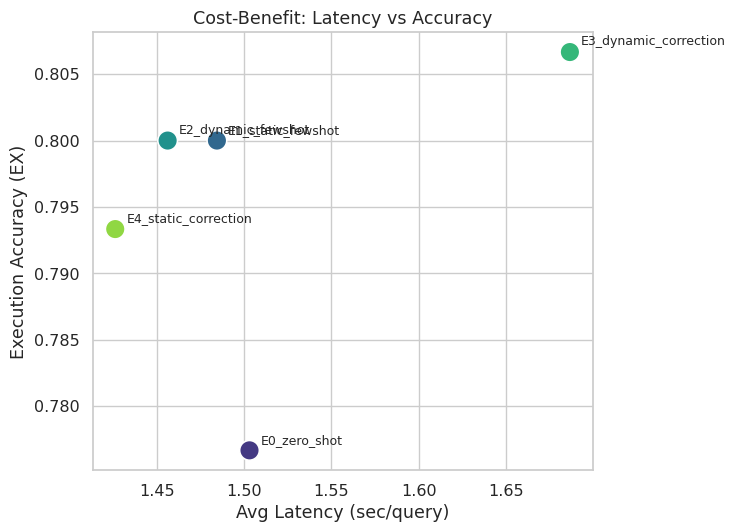

In [69]:
cond_stats = results_df[results_df["condition"].isin(CONDITION_ORDER)].groupby("condition").agg(
    EX_mean=("EX", "mean"), latency_mean=("latency_sec", "mean")
).reindex(CONDITION_ORDER).reset_index()

plt.figure(figsize=(7.5, 5.5))
ax = sns.scatterplot(data=cond_stats, x="latency_mean", y="EX_mean", hue="condition", s=200, palette="viridis")
for _, row in cond_stats.iterrows():
    ax.annotate(row["condition"], (row["latency_mean"], row["EX_mean"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel("Avg Latency (sec/query)")
ax.set_ylabel("Execution Accuracy (EX)")
ax.set_title("Cost-Benefit: Latency vs Accuracy")
ax.get_legend().remove()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_latency_vs_ex.png", dpi=300, bbox_inches="tight")
plt.show()


### Fig 5 — Error Taxonomy (execution-time errors)

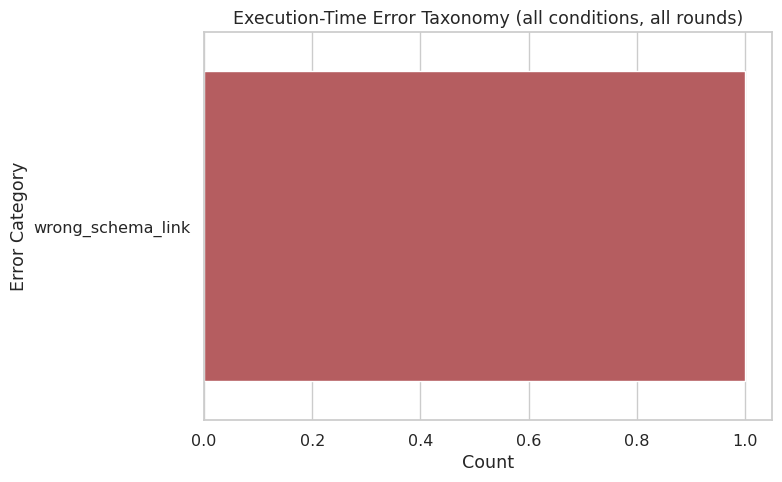


Luu y: bang tren CHI gom loi execution-time (bat tu SQLite traceback).
Loi semantic (SQL chay duoc nhung sai ket qua) nam rieng trong manual_review_semantic_errors.csv, can code tay bo sung vao Fig 5.


In [70]:
error_dist = traces_df[traces_df["error_category"] != "success"]["error_category"].value_counts().reset_index()
error_dist.columns = ["error_category", "count"]
error_dist = error_dist.sort_values("count")

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=error_dist, y="error_category", x="count", color="#C44E52", orient="h")
ax.set_xlabel("Count")
ax.set_ylabel("Error Category")
ax.set_title("Execution-Time Error Taxonomy (all conditions, all rounds)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_error_taxonomy.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nLuu y: bang tren CHI gom loi execution-time (bat tu SQLite traceback).")
print("Loi semantic (SQL chay duoc nhung sai ket qua) nam rieng trong manual_review_semantic_errors.csv, can code tay bo sung vao Fig 5.")


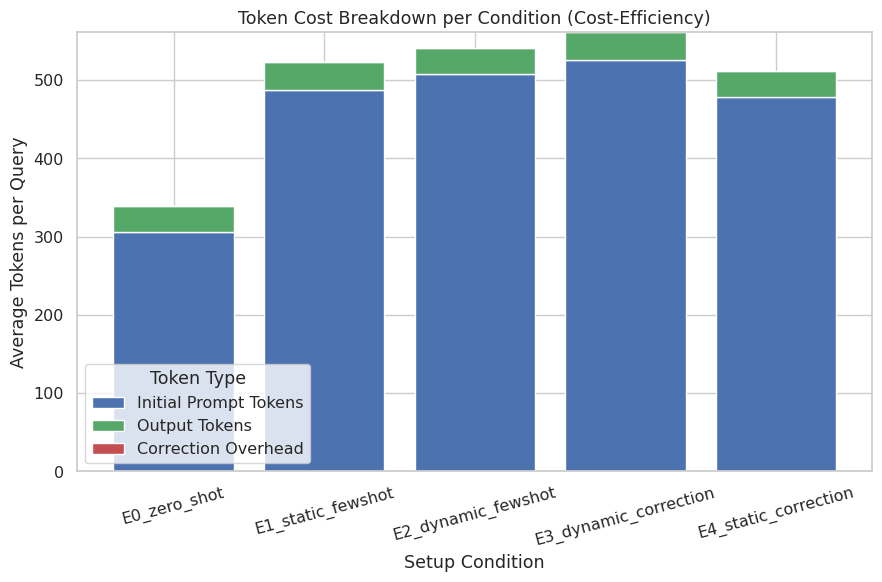

Đã lưu Fig 6: Token Cost Breakdown.


In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

WORK_DIR = Path("/kaggle/working")
FIG_DIR = WORK_DIR / "figures"
sns.set_theme(style="whitegrid", font_scale=1.05)

# Đọc data (đảm bảo bạn đã chạy phần Table 2 trong notebook)
try:
    table2_df = pd.read_csv(WORK_DIR / "table2_token_cost.csv")
    
    plt.figure(figsize=(9, 6))
    
    # Thiết lập dữ liệu cho Stacked Bar
    conditions = table2_df["condition"]
    prompt_tokens = table2_df["prompt_tokens_round1_mean"]
    output_tokens = table2_df["output_tokens_final_mean"]
    overhead_tokens = table2_df["correction_overhead_tokens_est"]

    # Vẽ từng lớp (Layer)
    p1 = plt.bar(conditions, prompt_tokens, color='#4C72B0', label='Initial Prompt Tokens')
    p2 = plt.bar(conditions, output_tokens, bottom=prompt_tokens, color='#55A868', label='Output Tokens')
    p3 = plt.bar(conditions, overhead_tokens, bottom=prompt_tokens + output_tokens, color='#C44E52', label='Correction Overhead')

    plt.xlabel("Setup Condition")
    plt.ylabel("Average Tokens per Query")
    plt.title("Token Cost Breakdown per Condition (Cost-Efficiency)")
    plt.xticks(rotation=15)
    plt.legend(title="Token Type")
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig6_token_cost_breakdown.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Đã lưu Fig 6: Token Cost Breakdown.")
except FileNotFoundError:
    print("Chưa tìm thấy table2_token_cost.csv. Hãy đảm bảo bạn đã chạy cell tính Table 2.")

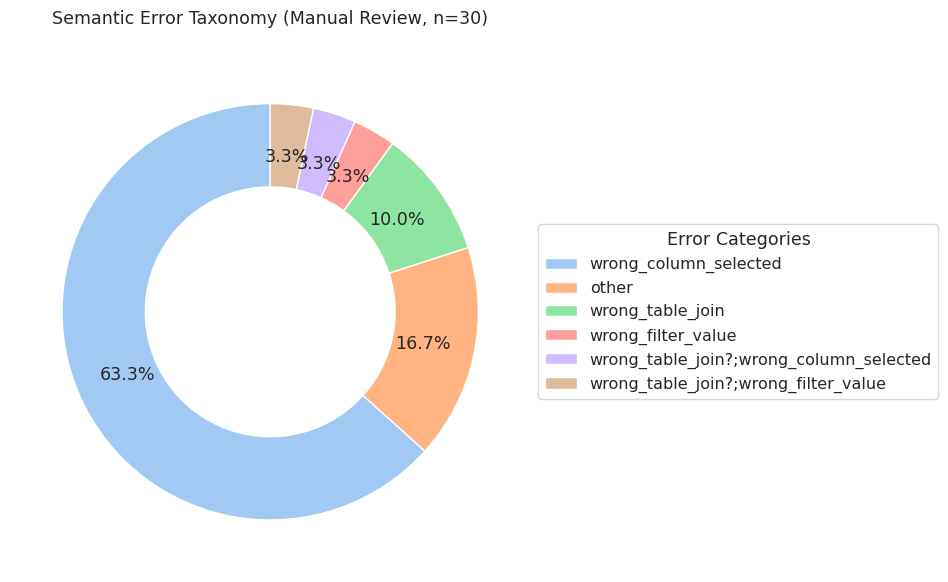

Đã lưu đè Fig 7 mới: Semantic Error Taxonomy.


In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

WORK_DIR = Path("/kaggle/working")
FIG_DIR = WORK_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Trỏ đúng đường dẫn tới file CSV của bạn
semantic_df = pd.read_csv("/kaggle/input/datasets/anvhng/my-manual-review/manual_review_semantic_errors.csv")

# Lọc bỏ các dòng chưa được đánh nhãn
labeled_errors = semantic_df[semantic_df["error_category"].notna() & (semantic_df["error_category"] != "")]

if len(labeled_errors) > 0:
    error_counts = labeled_errors["error_category"].value_counts()
    
    # Mở rộng chiều ngang của ảnh để có chỗ trống đặt bảng chú thích
    plt.figure(figsize=(9, 6))
    colors = sns.color_palette("pastel")[0:len(error_counts)]
    
    # Vẽ Donut Chart (TẮT labels để chữ không dính vào bánh)
    wedges, texts, autotexts = plt.pie(
        error_counts, 
        colors=colors, 
        autopct='%1.1f%%', 
        startangle=90, 
        pctdistance=0.75, 
        wedgeprops=dict(width=0.4, edgecolor='w'),
        labels=None  # <-- Điểm mấu chốt: Tắt nhãn dính trên biểu đồ
    )
    
    plt.title(f"Semantic Error Taxonomy (Manual Review, n={len(labeled_errors)})", pad=20)
    
    # Thêm bảng chú thích (Legend) sang lề bên phải
    plt.legend(
        wedges, error_counts.index,
        title="Error Categories",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1) # Đẩy legend ra ngoài khung bánh
    )
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig7_semantic_error_taxonomy.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Đã lưu đè Fig 7 mới: Semantic Error Taxonomy.")
else:
    print("File trống cột 'error_category'.")

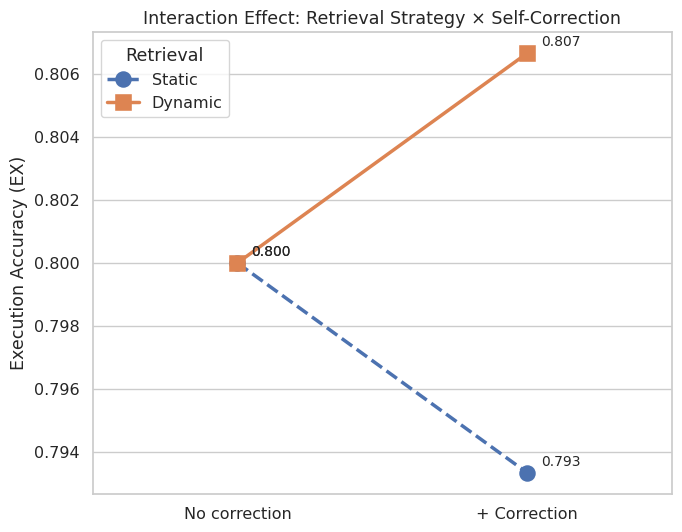

Do doc duong 'Dynamic' (E2->E3): +0.0067
Do doc duong 'Static'  (E1->E4): -0.0067
2 duong cang khac do doc (khong song song) -> interaction cang manh.


In [81]:
# ==== INSIGHT 1: Interaction Effect Plot (Retrieval x Correction, 2x2 factorial) ====
ex_means = results_df.groupby("condition")["EX"].mean()

interaction_df = pd.DataFrame({
    "correction": ["No correction", "No correction", "+ Correction", "+ Correction"],
    "retrieval": ["Static", "Dynamic", "Static", "Dynamic"],
    "EX": [
        ex_means["E1_static_fewshot"],
        ex_means["E2_dynamic_fewshot"],
        ex_means["E4_static_correction"],
        ex_means["E3_dynamic_correction"],
    ],
})

plt.figure(figsize=(7, 5.5))
ax = sns.pointplot(
    data=interaction_df, x="correction", y="EX", hue="retrieval",
    order=["No correction", "+ Correction"], markers=["o", "s"], linestyles=["--", "-"],
    palette={"Static": "#4C72B0", "Dynamic": "#DD8452"}, markersize=10, linewidth=2.5,
)
for _, row in interaction_df.iterrows():
    x_pos = 0 if row["correction"] == "No correction" else 1
    ax.annotate(f"{row['EX']:.3f}", (x_pos, row["EX"]), textcoords="offset points",
                xytext=(10, 5), fontsize=10)
ax.set_ylabel("Execution Accuracy (EX)")
ax.set_xlabel("")
ax.set_title("Interaction Effect: Retrieval Strategy × Self-Correction")
ax.legend(title="Retrieval")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_interaction_effect.png", dpi=300, bbox_inches="tight")
plt.show()

delta_dynamic = ex_means["E3_dynamic_correction"] - ex_means["E2_dynamic_fewshot"]
delta_static = ex_means["E4_static_correction"] - ex_means["E1_static_fewshot"]
print(f"Do doc duong 'Dynamic' (E2->E3): {delta_dynamic:+.4f}")
print(f"Do doc duong 'Static'  (E1->E4): {delta_static:+.4f}")
print("2 duong cang khac do doc (khong song song) -> interaction cang manh.")

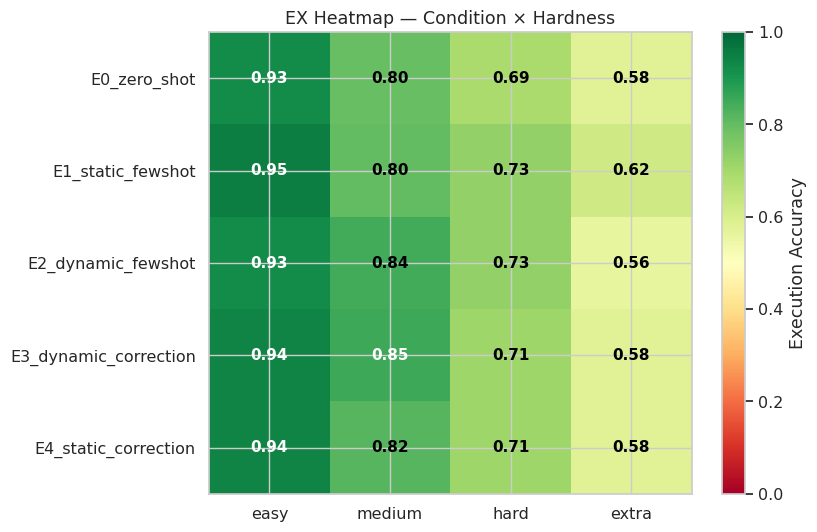

In [82]:
# ==== INSIGHT 2: Condition x Hardness Heatmap (KHONG dung .pivot()/.unstack()/sns.heatmap()) ====
conditions = [c for c in CONDITION_ORDER if c in results_df["condition"].unique()]
hardness_levels = [h for h in HARDNESS_ORDER if h in results_df["hardness"].unique()]

matrix = np.full((len(conditions), len(hardness_levels)), np.nan)
for i, cond in enumerate(conditions):
    for j, hd in enumerate(hardness_levels):
        sub = results_df[(results_df["condition"] == cond) & (results_df["hardness"] == hd)]
        if len(sub) > 0:
            matrix[i, j] = sub["EX"].mean()

fig, ax = plt.subplots(figsize=(1.6 * len(hardness_levels) + 2, 0.7 * len(conditions) + 2))
im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(hardness_levels))); ax.set_xticklabels(hardness_levels)
ax.set_yticks(range(len(conditions))); ax.set_yticklabels(conditions)
for i in range(len(conditions)):
    for j in range(len(hardness_levels)):
        val = matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                     color="white" if (val < 0.4 or val > 0.85) else "black", fontsize=11, fontweight="bold")
ax.set_title("EX Heatmap — Condition × Hardness")
plt.colorbar(im, ax=ax, label="Execution Accuracy")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_heatmap_condition_hardness.png", dpi=300, bbox_inches="tight")
plt.show()

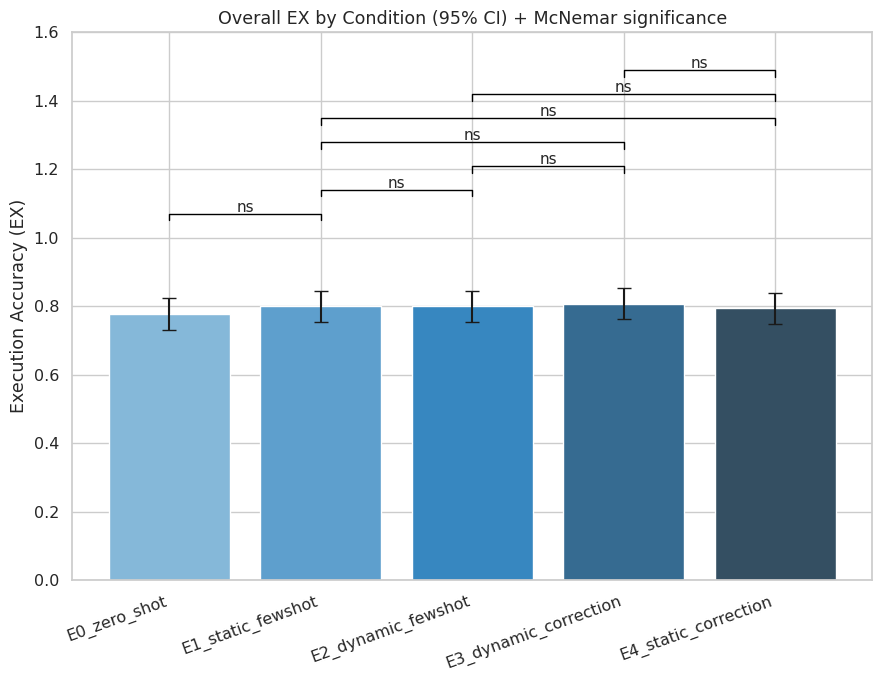

In [83]:
# ==== INSIGHT 3: EX bar chart + significance brackets tu McNemar ====
mcnemar_df = pd.read_csv(WORK_DIR / "mcnemar_pairwise.csv")

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

order = [c for c in CONDITION_ORDER if c in results_df["condition"].unique()]
ex_by_cond = results_df[results_df["condition"].isin(order)].groupby("condition")["EX"].agg(["mean", "count"])
ex_by_cond["se"] = np.sqrt(ex_by_cond["mean"] * (1 - ex_by_cond["mean"]) / ex_by_cond["count"])

plt.figure(figsize=(9, 7))
x_pos = np.arange(len(order))
plt.bar(x_pos, [ex_by_cond.loc[c, "mean"] for c in order],
        yerr=[1.96 * ex_by_cond.loc[c, "se"] for c in order], capsize=5,
        color=sns.color_palette("Blues_d", len(order)))
plt.xticks(x_pos, order, rotation=20, ha="right")
plt.ylabel("Execution Accuracy (EX)")
plt.title("Overall EX by Condition (95% CI) + McNemar significance")
plt.ylim(0, 1.6)

y_offset = 1.05
for _, row in mcnemar_df.iterrows():
    a, b = row["pair"].split(" vs ")
    if a in order and b in order:
        i, j = sorted([order.index(a), order.index(b)])
        star = p_to_star(row["p_value"])
        plt.plot([i, i, j, j], [y_offset, y_offset + 0.02, y_offset + 0.02, y_offset], color="black", linewidth=1)
        plt.text((i + j) / 2, y_offset + 0.025, star, ha="center", fontsize=11)
        y_offset += 0.07

plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_ex_significance.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_58/2002199734.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Error category", bbox_to_anchor=(1.02, 1), loc="upper left")


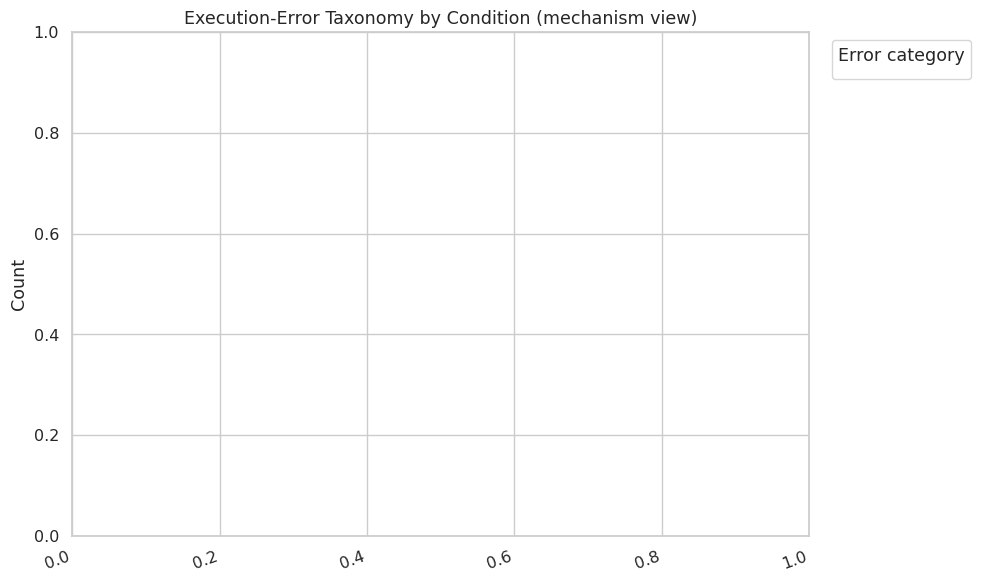

In [84]:
# ==== INSIGHT 4: Execution-error taxonomy THEO TUNG dieu kien ====
err_by_cond = (
    traces_df[traces_df["error_category"] != "success"]
    .groupby(["condition", "error_category"]).size()
    .reset_index(name="count")
)
conditions_present = [c for c in CONDITION_ORDER if c in err_by_cond["condition"].unique()]
categories_present = sorted(err_by_cond["error_category"].unique())

mat = np.zeros((len(conditions_present), len(categories_present)))
for i, cond in enumerate(conditions_present):
    for j, cat in enumerate(categories_present):
        row = err_by_cond[(err_by_cond["condition"] == cond) & (err_by_cond["error_category"] == cat)]
        mat[i, j] = row["count"].values[0] if len(row) else 0

plt.figure(figsize=(10, 6))
bottom = np.zeros(len(conditions_present))
colors = sns.color_palette("Set2", len(categories_present))
for j, cat in enumerate(categories_present):
    plt.bar(conditions_present, mat[:, j], bottom=bottom, label=cat, color=colors[j])
    bottom += mat[:, j]
plt.xticks(rotation=20, ha="right")
plt.ylabel("Count")
plt.title("Execution-Error Taxonomy by Condition (mechanism view)")
plt.legend(title="Error category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_error_taxonomy_by_condition.png", dpi=300, bbox_inches="tight")
plt.show()

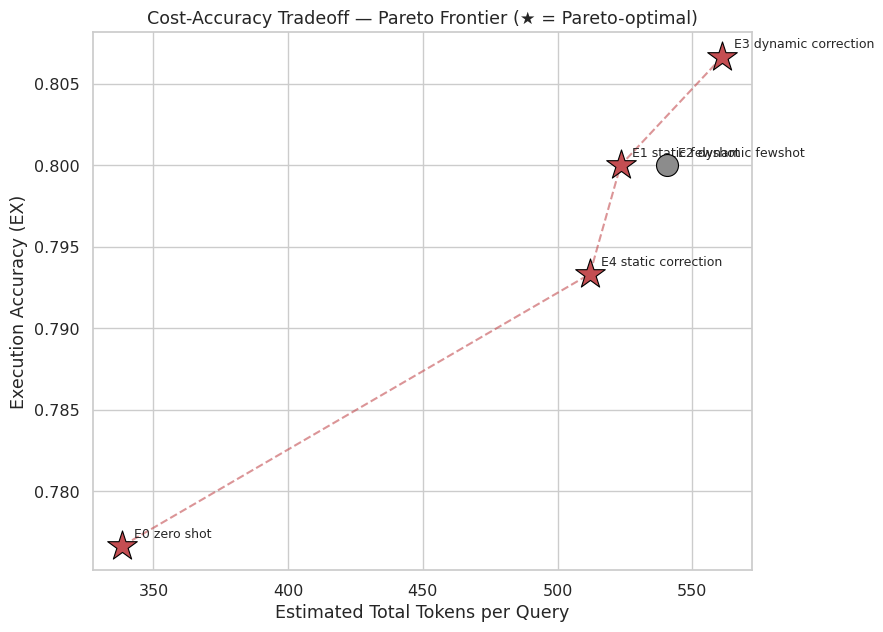

In [85]:
# ==== INSIGHT 5: Cost-Accuracy Pareto Frontier ====
table2_df = pd.read_csv(WORK_DIR / "table2_token_cost.csv")
merged = table2_df.merge(ex_by_cond.reset_index()[["condition", "mean"]], on="condition").rename(columns={"mean": "EX"})

def is_pareto_optimal(row, df):
    dominated = df[(df["total_tokens_per_query_est"] <= row["total_tokens_per_query_est"]) &
                   (df["EX"] >= row["EX"]) & (df["condition"] != row["condition"])]
    return len(dominated) == 0

merged["pareto_optimal"] = merged.apply(lambda r: is_pareto_optimal(r, merged), axis=1)

plt.figure(figsize=(9, 6.5))
for _, row in merged.iterrows():
    color = "#C44E52" if row["pareto_optimal"] else "#8C8C8C"
    marker = "*" if row["pareto_optimal"] else "o"
    size = 500 if row["pareto_optimal"] else 250
    plt.scatter(row["total_tokens_per_query_est"], row["EX"], s=size, color=color, marker=marker,
                edgecolor="black", linewidth=0.8, zorder=3)
    plt.annotate(row["condition"].replace("_", " "), (row["total_tokens_per_query_est"], row["EX"]),
                 textcoords="offset points", xytext=(8, 6), fontsize=9)

pareto_pts = merged[merged["pareto_optimal"]].sort_values("total_tokens_per_query_est")
plt.plot(pareto_pts["total_tokens_per_query_est"], pareto_pts["EX"], "--", color="#C44E52", alpha=0.6, zorder=2)
plt.xlabel("Estimated Total Tokens per Query")
plt.ylabel("Execution Accuracy (EX)")
plt.title("Cost-Accuracy Tradeoff — Pareto Frontier (★ = Pareto-optimal)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_pareto_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

              condition  round  n_recovered  pct_of_total
0  E4_static_correction      0          300         100.0
1  E4_static_correction      1            0           0.0
2  E4_static_correction      2            0           0.0
3  E4_static_correction  never            0           0.0


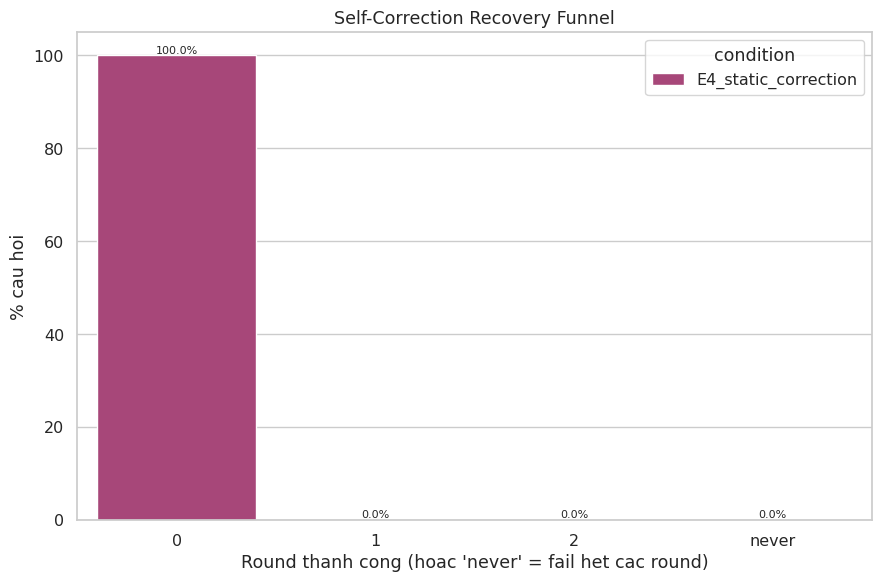

In [86]:
# ==== INSIGHT 6: Self-Correction Recovery Funnel (tung cau hoi duoc cuu o round nao) ====
funnel_rows = []
for cond in ["E3_dynamic_correction", "E4_static_correction"]:
    cond_traces = traces_df[traces_df["condition"] == cond]
    if len(cond_traces) == 0:
        continue
    first_success = []
    for (q, db), g in cond_traces.groupby(["question", "db_id"]):
        g_sorted = g.sort_values("round")
        ok = g_sorted[g_sorted["error"].isna()]
        first_success.append(int(ok["round"].min()) if len(ok) > 0 else -1)
    total = len(first_success)
    for r in [0, 1, 2]:
        n = sum(1 for x in first_success if x == r)
        funnel_rows.append({"condition": cond, "round": str(r), "n_recovered": n, "pct_of_total": n / total * 100})
    never = sum(1 for x in first_success if x == -1)
    funnel_rows.append({"condition": cond, "round": "never", "n_recovered": never, "pct_of_total": never / total * 100})

funnel_df = pd.DataFrame(funnel_rows)
print(funnel_df)

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=funnel_df, x="round", y="pct_of_total", hue="condition",
                  order=["0", "1", "2", "never"], palette="magma")
ax.set_xlabel("Round thanh cong (hoac 'never' = fail het cac round)")
ax.set_ylabel("% cau hoi")
ax.set_title("Self-Correction Recovery Funnel")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig11_correction_funnel.png", dpi=300, bbox_inches="tight")
plt.show()
funnel_df.to_csv(WORK_DIR / "correction_funnel.csv", index=False)

### Table 2 (tùy chọn) — Token/Cost breakdown
**Chưa có data** — Phase 2 hiện chỉ log `latency_sec`, không log token count mỗi request. Nếu muốn Table 2 đầy đủ, cần thêm field `usage_metadata` từ response Gemini vào `call_llm()`/`generate_sql()` và chạy lại batch — tốn thêm ~1800 request. Nếu deadline gấp, có thể bỏ qua Table 2 hoặc ước lượng thô bằng `len(prompt.split())` (không chính xác bằng token thật nhưng đủ minh hoạ xu hướng, không cần gọi lại API).

In [71]:
# Table 2 THAT: dung Gemini tokenizer that (client.models.count_tokens) thay vi dem tu (proxy cu).
# count_tokens() CHI tokenize, KHONG sinh output -> gan nhu mien phi, khong dung budget generation con lai.

def count_tokens_safe(text):
    try:
        r = gemini_client.models.count_tokens(model=LLM_MODEL, contents=str(text))
        return r.total_tokens
    except Exception:
        return np.nan

# Che do build_prompt tuong ung tung dieu kien (dung cho reconstruct round-1 prompt, deterministic)
prompt_mode_map = {
    "E0_zero_shot": "zero_shot",
    "E1_static_fewshot": "static",
    "E2_dynamic_fewshot": "dynamic",
    "E3_dynamic_correction": "dynamic",
    "E4_static_correction": "static",
}
cond_k_map = {**{n: c["k"] for n, c in CONDITIONS.items()}, **{n: c["k"] for n, c in CONDITIONS_E4.items()}}

SAMPLE_FOR_TOKENS = 60  # sample con moi dieu kien de gioi han so lan goi count_tokens (van du on dinh cho trung binh)

token_rows = []
for cond in CONDITION_ORDER:
    cond_df = results_df[results_df["condition"] == cond]
    sub = cond_df.sample(n=min(SAMPLE_FOR_TOKENS, len(cond_df)), random_state=SEED)
    in_toks, out_toks = [], []
    for _, row in sub.iterrows():
        p = build_prompt(row["question"], row["db_id"], k=cond_k_map[cond], mode=prompt_mode_map[cond])
        in_toks.append(count_tokens_safe(p))
        out_toks.append(count_tokens_safe(row["pred_sql"]))
    token_rows.append({
        "condition": cond,
        "prompt_tokens_round1_mean": round(float(np.nanmean(in_toks)), 1),
        "output_tokens_final_mean": round(float(np.nanmean(out_toks)), 1),
        "avg_rounds_used": round(cond_df["rounds_used"].mean() + 1, 2),
    })

table2_df = pd.DataFrame(token_rows)


def correction_overhead_tokens(tagged_csv):
    """Uoc luong so token THEM VAO do cac round sua loi (chi ap dung E3/E4).
    Doc tu traces_e{3,4}_tagged.csv (co cot 'condition' sach, khong dinh loi thieu cot cua Phase 2)."""
    path = WORK_DIR / tagged_csv
    if not path.exists():
        return 0.0
    tdf = pd.read_csv(path)
    extra = tdf[tdf["round"] > 0]
    if len(extra) == 0:
        return 0.0
    inject_texts = (
        "\n\n-- Cau SQL truoc bi loi:\n" + extra["sql"].astype(str)
        + "\n-- Loi tra ve:\n" + extra["error"].astype(str)
        + "\n-- Sua lai, chi tra ve SQL:"
    )
    sampled = inject_texts.sample(n=min(40, len(inject_texts)), random_state=SEED)
    toks = [count_tokens_safe(t) for t in sampled]
    avg_extra_rounds = tdf.groupby(["question", "db_id"])["round"].max().mean()  # so round vuot qua round 0, trung binh
    return round(float(np.nanmean(toks)) * max(avg_extra_rounds, 0), 1)


overhead_map = {
    "E3_dynamic_correction": correction_overhead_tokens("traces_e3_tagged.csv"),
    "E4_static_correction": correction_overhead_tokens("traces_e4_tagged.csv"),
}
table2_df["correction_overhead_tokens_est"] = table2_df["condition"].map(overhead_map).fillna(0.0)
table2_df["total_tokens_per_query_est"] = (
    table2_df["prompt_tokens_round1_mean"]
    + table2_df["output_tokens_final_mean"]
    + table2_df["correction_overhead_tokens_est"]
)

print(table2_df)
table2_df.to_csv(WORK_DIR / "table2_token_cost.csv", index=False)
print("\nLuu y (ghi vao Limitations): prompt_tokens_round1 va output_tokens la tokenizer that (count_tokens),")
print("nhung correction_overhead la uoc luong tu SAMPLE 40 doan chen loi (khong phai toan bo), va tong")
print("khong tinh phi thuc te cua nha cung cap (chi la don vi token, quy doi USD can bang gia hien hanh cua Gemini).")


               condition  prompt_tokens_round1_mean  output_tokens_final_mean  \
0           E0_zero_shot                      305.4                      33.1   
1      E1_static_fewshot                      487.9                      35.5   
2     E2_dynamic_fewshot                      508.3                      32.4   
3  E3_dynamic_correction                      525.3                      35.9   
4   E4_static_correction                      478.5                      33.5   

   avg_rounds_used  correction_overhead_tokens_est  total_tokens_per_query_est  
0              1.0                             0.0                       338.5  
1              1.0                             0.0                       523.4  
2              1.0                             0.0                       540.7  
3              1.0                             0.0                       561.2  
4              1.0                             0.0                       512.0  

Luu y (ghi vao Limitations

# Phase 4: Manuscript Skeleton (IMRAD)

Ban duoi day la khung viet san bang tieng Anh (dung ngon ngu bai paper NLP quoc te), da dien
san lap luan cho 3 rui ro reject chinh. **Cho vao ngoac vuong `[ ]` la noi phai dien so lieu
that** sau khi chay xong E4 + McNemar + Table 2 o tren. Copy tung phan vao LaTeX/Word, khong
copy nguyen mau vao noi khac vi day la ban nhap can bien tap them cau chu.

---

## 1. Abstract (draft)

Text-to-SQL systems built on general-purpose LLMs remain sensitive to two failure modes:
irrelevant or insufficient in-context examples, and single-shot generation with no mechanism
to recover from executable-but-wrong SQL. We study two complementary remedies — retrieval-
augmented dynamic few-shot selection (via FAISS over the Spider training set) and an
automated, execution-feedback-driven self-correction loop (up to 3 rounds) — and, critically,
their **interaction**. Using a 2x2 ablation on `gemini-2.5-flash` over a stratified 300-query
sample of Spider's dev set (E0 zero-shot, E1 static few-shot, E2 dynamic few-shot, E3
dynamic + correction, **E4 static + correction**), we find [SUMMARY OF DIRECTION: correction
helps more/less when combined with dynamic retrieval than with static retrieval], an effect of
[INTERACTION EFFECT VALUE] in Execution Accuracy (McNemar p=[P_VALUE]). We further report a
token-cost breakdown showing self-correction's overhead is [X]% of total prompt+output tokens,
and a manually-coded failure taxonomy separating execution-time errors from semantic errors
that survive execution. Results are stratified by Spider's official hardness levels
(easy/medium/hard/extra-hard), revealing that gains from both components are concentrated in
[HARDNESS BUCKET(S)] queries rather than uniform across difficulty.

## 2. Introduction (talking points, not final prose)

- Motivate with the standard Text-to-SQL pain points on complex schemas: schema linking
  errors, wrong joins/aggregations, and brittle single-shot generation.
- Gap: most few-shot Text-to-SQL pipelines use *static* exemplars chosen once, regardless of
  the input question's syntactic/semantic shape; this wastes context on irrelevant examples
  and may not surface the join/aggregation pattern the current question actually needs.
- Second gap: even strong LLMs occasionally produce SQL that is syntactically invalid or
  references non-existent columns; without a feedback loop, these are simply scored as
  failures instead of being corrected.
- Contribution framing (be explicit, this pre-empts "incremental" reviews):
  1. We isolate the *marginal* and *interactive* contribution of dynamic retrieval and
     self-correction via a full 2x2 ablation (E1/E2/E3/E4), not just a top-line
     "our full system vs baseline" comparison.
  2. We stratify every result by official Spider hardness and report paired statistical
     tests (McNemar), not just aggregate accuracy deltas.
  3. We report a real (tokenizer-measured) cost breakdown of the correction loop, addressing
     the common omission of efficiency reporting in self-refinement papers.

## 3. Related Work (positioning only — cite by name, do not fabricate quotes/details)

- **Text-to-SQL on Spider**: mention schema-aware encoder-decoder / graph-based approaches
  (e.g., RESDSQL-style schema linking) as the pre-LLM baseline family this work does not aim
  to beat on leaderboard terms (see Limitations — no fine-tuned-model comparison).
- **Prompting strategies for Text-to-SQL with LLMs**: DIN-SQL (decomposed prompting), C3
  (calibration + consistency) as examples of prompt-engineering-heavy pipelines without a
  learned retrieval component for exemplar selection.
- **Self-refinement / self-debugging**: Self-Debug and related execution-feedback loops as
  the direct precedent for our correction mechanism; note that most such work studies
  correction in isolation, rarely crossed with a retrieval-quality axis — this is exactly the
  gap E1-E4 fills.
- Close with one sentence: prior work treats retrieval-quality and self-correction as
  separate levers; this paper is (to our knowledge) among the few to cross them factorially
  on the same benchmark and model.

## 4. Methodology

### 4.1 Problem Formulation
Given natural-language question `q` and database schema `S_db`, generate SQL `y` such that
`execute(y, db) == execute(y*, db)` for gold SQL `y*` (Execution Accuracy, our primary
metric; see Section 5).

### 4.2 Component A — Dynamic Retrieval
- Embedding model: `all-MiniLM-L6-v2` (sentence-transformers), question-only embeddings.
- Index: FAISS `IndexFlatIP` over L2-normalized vectors (cosine similarity) built once over
  ~7000 Spider training questions.
- Retrieval: top-K same-`db_id` neighbors, with fallback to global top-K if fewer than K
  same-DB hits exist (rare, mostly small DBs).
- Compressed schema representation `table(col:type, col:type, ...)` used instead of verbose
  DDL to control prompt length — this choice is *why* Token Efficiency (Table 2) is a fair
  comparison across conditions rather than confounded by schema verbosity.

### 4.3 Component B — Self-Correction Loop
- Up to `MAX_ROUNDS=3`: on any SQLite execution error, the raw traceback is appended to the
  prompt with an explicit "fix it" instruction, and the LLM is re-queried.
- Execution guarded by a `threading.Timer`-based interrupt (not `signal.alarm`, since
  generation runs inside `ThreadPoolExecutor` worker threads) with a 5s timeout, itself
  logged as a `timeout` failure category if triggered.
- Justification for `max_rounds=3`: diminishing returns observed in per-round Correction
  Success Rate (Fig. 3) — report the actual round-1/2/3 success rates here once available.

### 4.4 Factorial Design and Interaction Effect
Explicitly present the 2x2 table (static vs dynamic retrieval) x (no correction vs
correction) = {E1, E2, E3, E4}, plus E0 as a zero-shot floor. Define the interaction effect
as `(EX_E3 - EX_E2) - (EX_E4 - EX_E1)` and report it alongside McNemar tests on the
(E3 vs E2) and (E4 vs E1) pairs — this is the single most important number for the
"is this incremental" rebuttal.

### 4.5 System Architecture Diagram
Block diagram: `Question -> Embed -> FAISS retrieve (skip if static/zero-shot) -> Prompt
assemble (schema + examples + question) -> LLM generate -> SQLite execute -> [on error, loop
back into prompt, max 3 rounds] -> Execution Accuracy scorer`.

## 5. Experimental Setup

- Dataset: Spider dev set, stratified random sample, `N=300`, `seed=42` (state explicitly
  that this is not the full dev set — see Limitations).
- Model: `gemini-2.5-flash`, `temperature=0`, accessed via the `google-genai` SDK, run on
  [DATE OF RUN].
- Hardness: computed with the *official* Spider evaluator (`taoyds/spider`,
  `Evaluator().eval_hardness`), not a custom heuristic.
- K-sweep: `K in {1,3,5,8,10}` for E2/E3 on a separate 100-query subset (state explicitly
  that this subset is smaller and does not include E4 — note as a Limitation / future work
  item if E4's K-sensitivity is not measured).
- Metrics: EX (primary), EM (secondary, reported but not emphasized due to brittleness to
  formatting), CSR by round, token cost (tokenizer-measured, Table 2), latency, failure
  taxonomy (execution-time, automatic; semantic, manually coded on a 50-case sample).
- Statistical testing: McNemar's test for all pairwise EX comparisons (paired binary
  outcomes on the same query set), 95% CI via seaborn `errorbar=("ci",95)` in Fig. 1.

## 6. Results

Structure this section strictly around the artifacts already produced:
- Table 1 (`table1_ex_by_hardness.csv`) + Fig. 1: EX by condition x hardness, all 5
  conditions now including E4.
- Fig. 2 (`ksweep_full.csv`): EX vs K for E2/E3 — report the saturation point.
- Fig. 3 (`traces_e3_tagged.csv`): CSR by round for E3 (and consider adding the same for E4
  if budget allows, for a cleaner correction-mechanism comparison independent of retrieval).
- Fig. 4 (`summary.csv`): latency vs EX cost-benefit scatter, now with E4 as a 5th point.
- Fig. 5 + `manual_review_semantic_errors.csv`: combined execution-time + manually-coded
  semantic failure taxonomy.
- Table 2 (`table2_token_cost.csv`): real tokenizer-based prompt/output/correction-overhead
  token counts per condition.
- McNemar table (`mcnemar_pairwise.csv`) + interaction-effect number: report inline as the
  key quantitative claim of the paper.

## 7. Discussion — do not avoid the awkward result

Write this section assuming E2/E3 do **not** uniformly beat E1 across hardness buckets (as
seen in the Phase-2 results: e.g. E2's `extra`-hardness EX is *below* E1's in the current
data). Concrete moves:

1. **Name it directly**: "Dynamic retrieval alone (E2) does not uniformly outperform static
   few-shot (E1); on `extra`-hardness queries EX is [X] vs [Y]. This suggests retrieval
   relevance helps example *format-matching* more than it helps *reasoning* on queries whose
   difficulty stems from multi-table joins/nesting rather than surface-level phrasing
   similarity to training questions."
2. **Redirect the interpretation to the interaction effect**: the paper's contribution is not
   "dynamic retrieval beats static retrieval in isolation" but "the *combination* with
   self-correction yields [INTERACTION EFFECT VALUE], significant at p=[P_VALUE] — i.e.,
   dynamic retrieval's value shows up mainly *conditional on* having a correction mechanism
   to exploit the more relevant (but not always sufficient) exemplars."
3. **Use the token-cost table to add a second axis of comparison**: even where EX gains are
   modest, report whether dynamic retrieval achieves comparable EX at lower/higher token cost
   than static (Table 2), which is a defensible claim independent of raw EX ranking.
4. **Where correction doesn't help**: describe hard/extra-hard cases where self-correction
   round 2/3 success rate collapses (Fig. 3) — likely queries with structurally wrong initial
   SQL (missing GROUP BY / wrong join) that a single traceback-based hint cannot fix, since
   SQLite errors are silent on *semantic* (non-executable-error) mistakes. This is exactly why
   the semantic-error manual coding (Section 12 of the notebook) matters: the execution-time
   taxonomy alone cannot explain correction's limits.

## 8. Limitations

- Evaluated on `N=300` stratified sample of Spider dev, not the full dev set, due to the
  48-hour compute/API budget; K-sweep used an even smaller `N=100` subset and (state
  explicitly) was not repeated for E4.
- Table 2's correction-overhead figures are estimated from a 40-sample subset of correction
  traces per condition (tokenizer-measured, not full-population), not a complete audit of
  every correction round.
- Manual semantic-error coding covers 50 cases (heuristic-hinted, human-labeled); this is a
  qualitative supplement, not a statistically powered failure-mode estimate.
- Single model version pinned (`gemini-2.5-flash`, run on [DATE]); no comparison to
  fine-tuned, Spider-leaderboard-specific models — this paper's claims are about
  *prompting-strategy* effects on a fixed general-purpose LLM, not SOTA Text-to-SQL accuracy.
- `temperature=0` reduces but does not eliminate API non-determinism; a single run per
  condition (no repeated-run variance estimate) — flag as an avenue for a rebuttal-stage
  robustness check if reviewers ask.

## 9. Conclusion

One paragraph, mirroring the Abstract's final two sentences but tying back to the interaction
number and stratified-hardness finding as the two headline takeaways. Avoid re-stating every
figure — that is what Section 6 is for.

---

### Checklist before submission-ready draft
- [ ] Fill every `[ ]` placeholder above with real numbers from `table1_ex_by_hardness.csv`,
      `table2_token_cost.csv`, `mcnemar_pairwise.csv`, and the interaction-effect print-out.
- [ ] Confirm all Phase 3 figures actually saved to `/kaggle/working/figures/` (300dpi PNG).
- [ ] Confirm `manual_review_semantic_errors.csv` has a fully filled (non-empty)
      `error_category` column before citing Fig. 5's semantic breakdown.
- [ ] Re-read Discussion Section 7 point 1 — do not let it get edited into something vaguer;
      the direct naming of the "E2 doesn't beat E1 everywhere" pattern is deliberate.


# EDA — Retrieval Corpus & Schema Analysis
Không dùng lại EDA kiểu tabular (phân phối/correlation trên feature số). Với RAG Text-to-SQL, EDA cần trả lời: **retrieval có tìm được ví dụ "cùng ngữ cảnh schema" hay chỉ "giống câu chữ"?** Toàn bộ cell dưới đây dùng lại `train_pairs`, `schema_cache`, `embedder`, `index`, `eval_set`, `results_df` đã có sẵn — **không gọi API**, không tốn tiền.

In [ ]:
# EDA 1: Train/Dev database co disjoint theo dung thiet ke Spider (cross-database benchmark) khong?
train_db_ids = set(p["db_id"] for p in train_pairs)
eval_db_ids = set(ex["db_id"] for ex in eval_set)
overlap_db_ids = train_db_ids & eval_db_ids

print(f"So DB trong train: {len(train_db_ids)}")
print(f"So DB trong eval_set (dev sample): {len(eval_db_ids)}")
print(f"So DB TRUNG giua train va eval_set: {len(overlap_db_ids)}")
print(f"-> {'Disjoint hoan toan (dung thiet ke cross-database cua Spider)' if len(overlap_db_ids)==0 else 'CO overlap: ' + str(overlap_db_ids)}")


### EDA 2 — Phân phối similarity score của retrieval (bằng chứng số liệu, không phải suy đoán)

In [ ]:
# EDA 2: Cosine similarity cua top-1 va trung binh top-K cho tung cau hoi trong eval_set
sim_records = []
for ex in eval_set:
    q_emb = embedder.encode([ex["question"]], normalize_embeddings=True).astype(np.float32)
    scores, idxs = index.search(q_emb, 20)  # over-fetch de loc theo db_id neu can
    same_db_scores = [scores[0][i] for i, idx in enumerate(idxs[0]) if train_pairs[idx]["db_id"] == ex["db_id"]]
    all_scores = scores[0][:TOP_K]
    sim_records.append({
        "question": ex["question"],
        "db_id": ex["db_id"],
        "top1_sim": float(scores[0][0]),
        "topk_mean_sim": float(np.mean(all_scores)),
        "n_same_db_in_top20": len(same_db_scores),  # co bao nhieu ket qua CUNG db trong 20 ung vien dau
    })

sim_df = pd.DataFrame(sim_records)
print(sim_df[["top1_sim", "topk_mean_sim", "n_same_db_in_top20"]].describe())
print(f"\n% cau hoi co it nhat 1 vi du CUNG DATABASE trong top-20 retrieve: {(sim_df['n_same_db_in_top20'] > 0).mean()*100:.1f}%")


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(sim_df["top1_sim"], bins=30, color="#4C72B0")
plt.axvline(sim_df["top1_sim"].mean(), color="red", linestyle="--", label=f"Mean = {sim_df['top1_sim'].mean():.3f}")
plt.xlabel("Cosine similarity (top-1 retrieved example)")
plt.ylabel("So cau hoi")
plt.title("Phan phoi Similarity Score cua Retrieval (eval_set)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "eda1_retrieval_similarity_dist.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nDIEN GIAI:")
print("- Similarity cao (>0.7-0.8) + retrieved db KHAC voi target db -> retrieval tim duoc cau HOI tuong tu nhung SAI ngu canh schema.")
print("- Day la bang chung so lieu cho gia thuyet: dynamic retrieval (E2) khong hon tinh (E1) vi Spider la cross-database benchmark.")


### EDA 3 — Schema overlap (Jaccard trên tên cột) giữa ví dụ retrieve được và database mục tiêu

In [ ]:
# EDA 3: Vi du retrieve duoc co CHIA SE ten cot voi target DB khong? (do truc tiep muc do "huu ich" cua vi du)
def parse_columns(schema_str: str) -> set:
    # schema_str dang: "table1(col1:type,col2:type) | table2(col3:type)"
    cols = set()
    for table_part in schema_str.split("|"):
        if "(" not in table_part:
            continue
        inner = table_part.split("(", 1)[1].rsplit(")", 1)[0]
        for col_def in inner.split(","):
            col_name = col_def.split(":")[0].strip().lower()
            if col_name:
                cols.add(col_name)
    return cols

def jaccard(a: set, b: set) -> float:
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

overlap_records = []
for ex in eval_set:
    target_cols = parse_columns(schema_cache.get(ex["db_id"], ""))
    top1_example = retrieve_topk(ex["question"], ex["db_id"], k=1)[0]
    retrieved_cols = parse_columns(schema_cache.get(top1_example["db_id"], ""))
    overlap_records.append({
        "question": ex["question"],
        "target_db": ex["db_id"],
        "retrieved_db": top1_example["db_id"],
        "same_db": ex["db_id"] == top1_example["db_id"],
        "column_jaccard": jaccard(target_cols, retrieved_cols),
    })

overlap_df = pd.DataFrame(overlap_records)
print(overlap_df["column_jaccard"].describe())
print(f"\n% cau hoi ma vi du top-1 retrieve TRUNG database voi target: {overlap_df['same_db'].mean()*100:.1f}%")
print(f"Column-name Jaccard trung binh (target vs vi du retrieve duoc): {overlap_df['column_jaccard'].mean():.3f}")


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(overlap_df["column_jaccard"], bins=25, color="#55A868")
plt.xlabel("Column-name Jaccard similarity (target DB vs retrieved example's DB)")
plt.ylabel("So cau hoi")
plt.title("Schema Overlap giua Target DB va Vi Du Retrieve (Top-1)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda2_schema_overlap.png", dpi=300, bbox_inches="tight")
plt.show()


### EDA 4 — Độ phức tạp schema (số bảng/cột) theo hardness, và tương quan với EX

In [ ]:
# EDA 4: Schema cang phuc tap (nhieu bang/cot) thi EX co giam khong? (doc lap voi hardness cua Spider)
def schema_size(schema_str: str) -> dict:
    n_tables = len([t for t in schema_str.split("|") if "(" in t])
    n_cols = len(parse_columns(schema_str))
    return {"n_tables": n_tables, "n_cols": n_cols}

schema_size_df = pd.DataFrame([
    {"db_id": db_id, **schema_size(s)} for db_id, s in schema_cache.items()
])

merged = results_df.merge(schema_size_df, on="db_id", how="left")
print(merged.groupby("hardness")[["n_tables", "n_cols"]].mean())
print(f"\nCorrelation(n_cols, EX): {merged['n_cols'].corr(merged['EX']):.3f}")
print(f"Correlation(n_tables, EX): {merged['n_tables'].corr(merged['EX']):.3f}")


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged, x="hardness", y="n_cols", order=HARDNESS_ORDER, palette="viridis")
plt.xlabel("Hardness (Spider official)")
plt.ylabel("So cot trong schema (target DB)")
plt.title("Do phuc tap Schema theo Hardness")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda3_schema_complexity_by_hardness.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nLUU Y: neu n_cols/n_tables KHONG tang deu theo hardness, chung to Spider hardness")
print("do do PHUC TAP CAU TRUC SQL (join/nested/agg), khong phai do KICH THUOC schema -- can noi ro trong Methodology.")


### Tóm tắt EDA cho Methodology/Discussion
Ghi vào Methodology (mô tả corpus) và Discussion (giải thích tại sao E2/E3 không vượt trội đáng kể E1):
1. **Cross-database design xác nhận bằng số liệu** (EDA 1) — không phải giả định, là fact đo được.
2. **Similarity score cao nhưng retrieved DB thường khác target DB** (EDA 2) → retrieval "đúng dạng câu hỏi, sai ngữ cảnh".
3. **Column-name Jaccard thấp** (EDA 3) → định lượng trực tiếp mức độ "vô ích" của ví dụ few-shot về mặt schema, giải thích vì sao 63% lỗi semantic là `wrong_column_selected`.
4. **Độ phức tạp schema vs hardness** (EDA 4) → làm rõ hardness của Spider đo cấu trúc câu SQL, không đơn thuần đo kích thước database — tránh nhầm lẫn khi diễn giải Fig 1.